In [58]:
import numpy as np
import matplotlib.pyplot as plt
import random

### Initialize

In [101]:
EPOCHS = 5000
n = 200
c = 0.01

In [102]:
def build_coordinate_matrices(n, c):
    mats = []
    for i in range(n):
        M = np.eye(n)
        M[i, i] = 0.0
        M[i, :] = -c  
        M[i, i] = 0.0  
        mats.append(M)
    return mats

def run_ccd(epochs, n, c): 
    I = np.identity(n)
    L = -np.tril(c * np.ones((n, n)), k=-1) 
    C = np.linalg.inv(I-L) @ L.T
    
    x0 = np.ones((n,1))
    x = x0.copy()
    x_star = np.zeros((n,1))
    ccd_errors = []
    
    for l in range(epochs):
        x = C @ x
        norm = np.linalg.norm(x - x_star)
        if norm < 1e-50:
            print(f"CCD converges at epoch {l}")
            break
        ratio = norm / np.linalg.norm(x0 - x_star)
        ccd_errors.append(np.log(ratio))
        
    return ccd_errors 

def run_rcd(epochs, n, c):
    I = np.identity(n)
    L = -np.tril(c * np.ones((n, n)), k=-1) 
    A_c = np.identity(n)- L - L.T
    S = np.diag([1/(n) for i in range(n)])
    R = np.linalg.matrix_power(I - S @ np.linalg.inv(I) @ A_c, n) 

    x0 = np.ones((n,1))
    x = x0.copy()
    x_star = np.zeros((n,1))
    rcd_errors = []
    
    for l in range(epochs):
        x = R @ x
        norm = np.linalg.norm(x - x_star)
        if norm < 1e-50:
            print(f"RCD converges at epoch {l}")
            break
        ratio = norm / np.linalg.norm(x0 - x_star)
        rcd_errors.append(np.log(ratio))

    return rcd_errors

def run_prcd(epochs, n, c): 
    mats = build_coordinate_matrices(n, c)
    epochs = 5000
    x0 = np.ones((n, 1))
    x = x0.copy()
    x_star = np.zeros((n, 1))
    prcd_errors = []
    
    for l in range(epochs):
        for i in range(n): 
            i = random.randint(0, n - 1)
            x = mats[i] @ x
        norm = np.linalg.norm(x - x_star)
        if norm < 1e-50:
            print(f"PRCD converges at iteration {l}")
            break
        else:
            ratio = norm / np.linalg.norm(x0 - x_star)
            prcd_errors.append(np.log(ratio))
            
    return prcd_errors

In [103]:
def plot_algo(epochs, n, c):
    ccd_errors, rcd_errors, prcd_errors = run_ccd(epochs, n, c), run_rcd(epochs, n, c), run_prcd(epochs, n, c)
    fix, ax = plt.subplots(figsize=(8,6))
    ccd = ax.plot(np.arange(len(ccd_errors)), ccd_errors, label="Rate(CCD)")
    rcd = ax.plot(np.arange(len(rcd_errors)), rcd_errors, label="ERate(RCD)")
    prcd = ax.plot(np.arange(len(prcd_errors)), prcd_errors, label="PRate(RCD)")

    rho_ccd = np.max(np.abs(np.linalg.eigvals(C)))
    rho_ercd = np.max(np.abs(np.linalg.eigvals(R)))
    rate_ccd = -np.log(rho_ccd)
    rate_ercd = -np.log(rho_ercd)
    print(f"Rate(CCD): {rate_ccd:.4f} | ERate(RCD): {rate_ercd:.4f} (From Spectral Radius)")

    ccd_slope, intercept = np.polyfit(range(len(ccd_errors)), ccd_errors, 1)
    ercd_slope, intercept = np.polyfit(range(len(rcd_errors)), rcd_errors, 1)
    prcd_slope, intercept = np.polyfit(range(len(prcd_errors)), prcd_errors, 1)
    print(f"Slope for Rate(CCD): {ccd_slope:.4f} | ERate(RCD): {ercd_slope:.4f} | PRate(RCD):{prcd_slope:.4f}")
    
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Error Log Ratio")
    ax.set_title("Algorithms Convergence Rate")
    ax.legend()

### Running 

CCD converges at epoch 127
RCD converges at epoch 88
PRCD converges at iteration 148
Rate(CCD): 0.9252 | ERate(RCD): 0.9925 (From Spectral Radius)
Slope for Rate(CCD): -0.9254 | ERate(RCD): -1.1336 | PRate(RCD):-0.8068


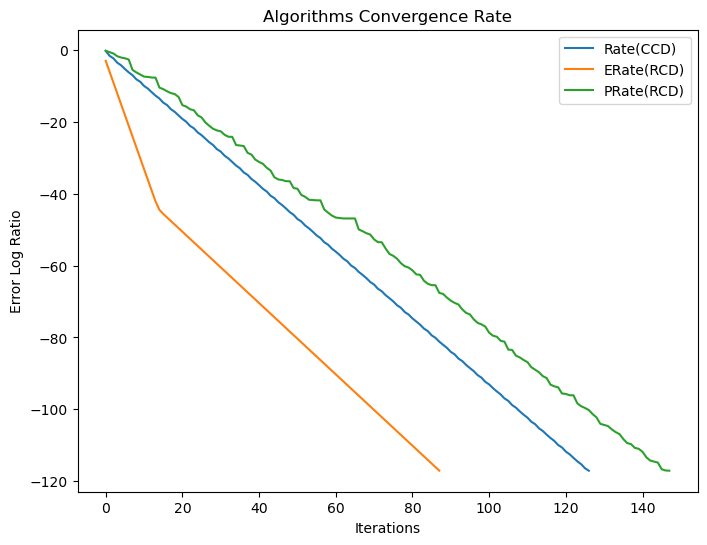

In [104]:
plot_algo(EPOCHS, n, c)

### Different n and c values

CCD converges at epoch 35
RCD converges at epoch 95
PRCD converges at iteration 101
CCD converges at epoch 46
RCD converges at epoch 85
PRCD converges at iteration 112
CCD converges at epoch 57
RCD converges at epoch 84
PRCD converges at iteration 124
CCD converges at epoch 66
RCD converges at epoch 87
PRCD converges at iteration 132
CCD converges at epoch 76
RCD converges at epoch 87
PRCD converges at iteration 141


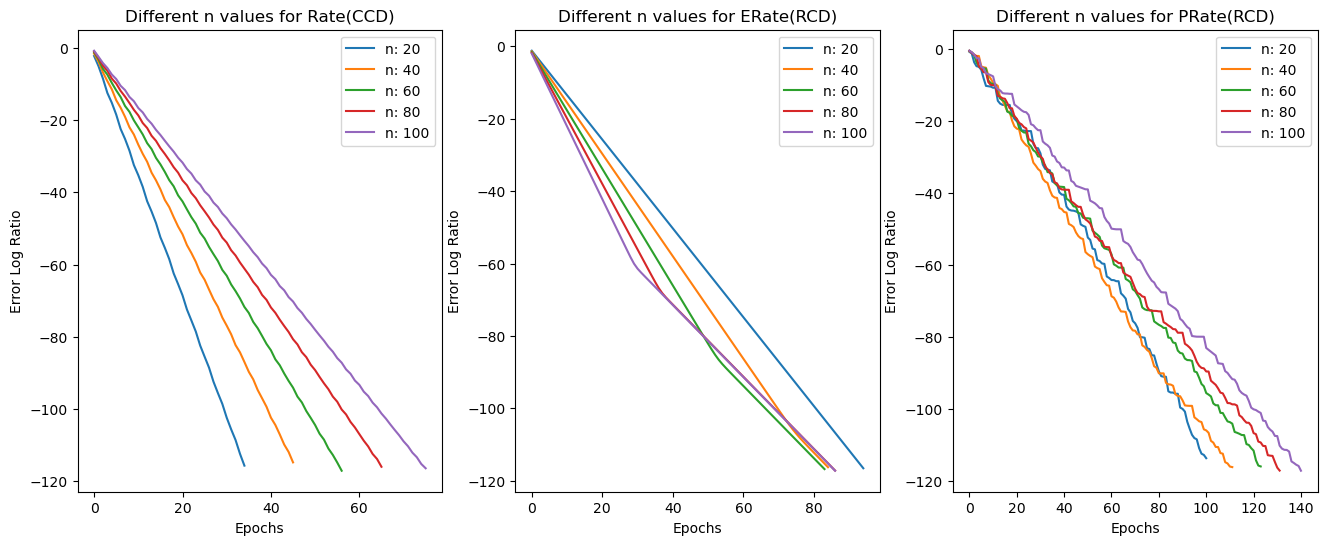

In [129]:
fix, axs = plt.subplots(ncols=3, nrows=1, figsize=(16, 6))
algo_list = ["Rate(CCD)", "ERate(RCD)", "PRate(RCD)"]
for dim in range(20, 101, 20):
    ccd_errors = run_ccd(EPOCHS, dim, c)
    rcd_errors = run_rcd(EPOCHS, dim, c)
    prcd_errors = run_prcd(EPOCHS, dim, c)
    
    ccd = axs[0].plot(np.arange(len(ccd_errors)), ccd_errors, label=f"n: {dim}")
    rcd = axs[1].plot(np.arange(len(rcd_errors)), rcd_errors, label=f"n: {dim}")
    prcd = axs[2].plot(np.arange(len(prcd_errors)), prcd_errors, label=f"n: {dim}")

    for i, algo in enumerate(algo_list):
        axs[i].set_xlabel("Epochs")
        axs[i].set_ylabel("Error Log Ratio")
        axs[i].set_title(f"Different n values for {algo}")
        axs[i].legend()

CCD converges at epoch 345
RCD converges at epoch 91
PRCD converges at iteration 169
CCD converges at epoch 52
RCD converges at epoch 83
PRCD converges at iteration 123
CCD converges at epoch 24
RCD converges at epoch 110
PRCD converges at iteration 86
CCD converges at epoch 16
RCD converges at epoch 115
PRCD converges at iteration 63
CCD converges at epoch 12
RCD converges at epoch 115
PRCD converges at iteration 51


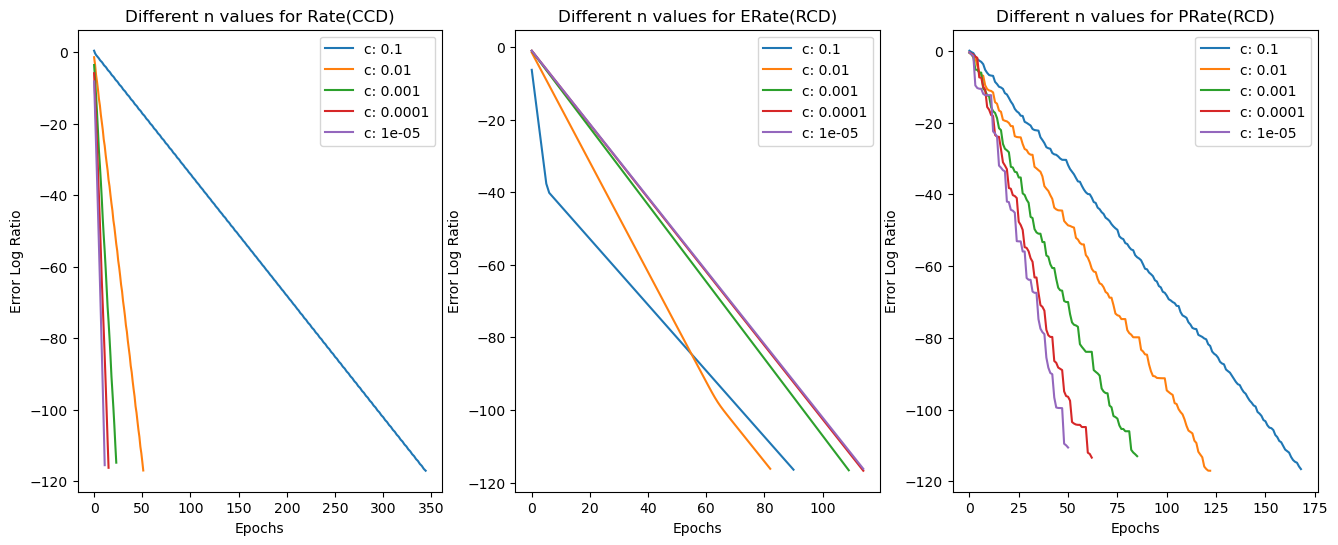

In [131]:
fix, axs = plt.subplots(ncols=3, nrows=1, figsize=(16, 6))
algo_list = ["Rate(CCD)", "ERate(RCD)", "PRate(RCD)"]
c_vals = [0.1, 0.01, 0.001, 0.0001, 0.00001]
dim = 50

for c in c_vals:
    ccd_errors = run_ccd(EPOCHS, dim, c)
    rcd_errors = run_rcd(EPOCHS, dim, c)
    prcd_errors = run_prcd(EPOCHS, dim, c)
    
    ccd = axs[0].plot(np.arange(len(ccd_errors)), ccd_errors, label=f"c: {c}")
    rcd = axs[1].plot(np.arange(len(rcd_errors)), rcd_errors, label=f"c: {c}")
    prcd = axs[2].plot(np.arange(len(prcd_errors)), prcd_errors, label=f"c: {c}")

    for i, algo in enumerate(algo_list):
        axs[i].set_xlabel("Epochs")
        axs[i].set_ylabel("Error Log Ratio")
        axs[i].set_title(f"Different n values for {algo}")
        axs[i].legend()